In [2]:
# IMPORTANT:
#   Whenever you start a new colab runtime, use the following code to download
#   the training dataset onto the runtime local storage.
#   This should take ~3-5 mins for the whole dataset.
#   You can then load data from the local storage (/content/data) into your colab
#   notebook using the `h5py` library (see example below).
from huggingface_hub import hf_hub_download
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="train.h5", repo_type="dataset", local_dir="data")
hf_hub_download(repo_id="benmoseley/ese-dl-2024-25-group-project", filename="events.csv", repo_type="dataset", local_dir="data")

train.h5:   0%|          | 0.00/10.7G [00:00<?, ?B/s]

events.csv:   0%|          | 0.00/782k [00:00<?, ?B/s]

'data/events.csv'

In [3]:
import pandas as pd
import h5py
import IPython
import PIL
import matplotlib.pyplot as plt
import os
import io

In [4]:
# this DataFrame contains all of the event meta data
df = pd.read_csv("data/events.csv", parse_dates=["start_utc"])
df

,id,img_type,start_utc,llcrnrlat,llcrnrlon,urcrnrlat,urcrnrlon,proj,height_m,width_m
0,S778114,ir069,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.944590,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
1,S778114,ir107,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.944590,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
2,S778114,lght,NaT,32.781533,-92.631841,35.944590,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3,S778114,vil,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.944590,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
4,S778114,vis,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.944590,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
...,...,...,...,...,...,...,...,...,...,...
3995,S832818,ir069,2019-07-28 17:44:00+00:00,46.493514,-100.371384,49.953392,-95.191216,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3996,S832818,ir107,2019-07-28 17:44:00+00:00,46.493514,-100.371384,49.953392,-95.191216,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3997,S832818,lght,NaT,46.493514,-100.371384,49.953392,-95.191216,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3998,S832818,vil,2019-07-28 17:45:00+00:00,46.493514,-100.371384,49.953392,-95.191216,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0


In [29]:
df.columns

Index(['id', 'img_type', 'start_utc', 'llcrnrlat', 'llcrnrlon', 'urcrnrlat',
       'urcrnrlon', 'proj', 'height_m', 'width_m'],
      dtype='object')

In [18]:

df["img_type"].unique()

array(['ir069', 'ir107', 'lght', 'vil', 'vis'], dtype=object)

In [5]:
print(f"Total number of events: {len(df.id.unique())}")

Total number of events: 800


In [6]:
# this function loads all of the image arrays for a given id
def load_event(id):
    "Load event"
    with h5py.File(f'data/train.h5','r') as f:
        event = {img_type: f[id][img_type][:] for img_type in ['vis', 'ir069', 'ir107', 'vil', 'lght']}
    return event

event = load_event("S778114")
for img_type in event:
    print(f"{img_type}: {event[img_type].shape} ({event[img_type].dtype})")

vis: (384, 384, 36) (int16)
ir069: (192, 192, 36) (int16)
ir107: (192, 192, 36) (int16)
vil: (384, 384, 36) (uint8)
lght: (38777, 5) (float32)


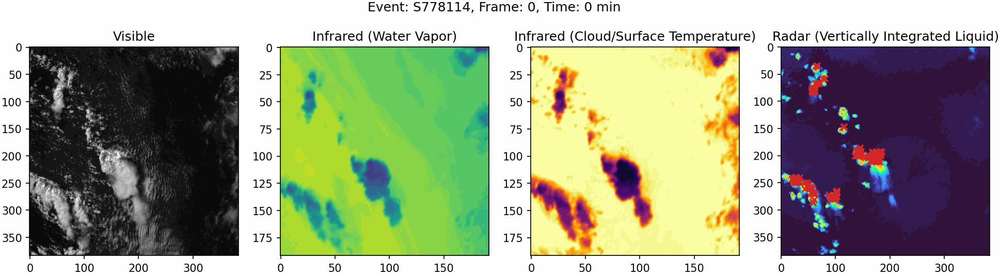

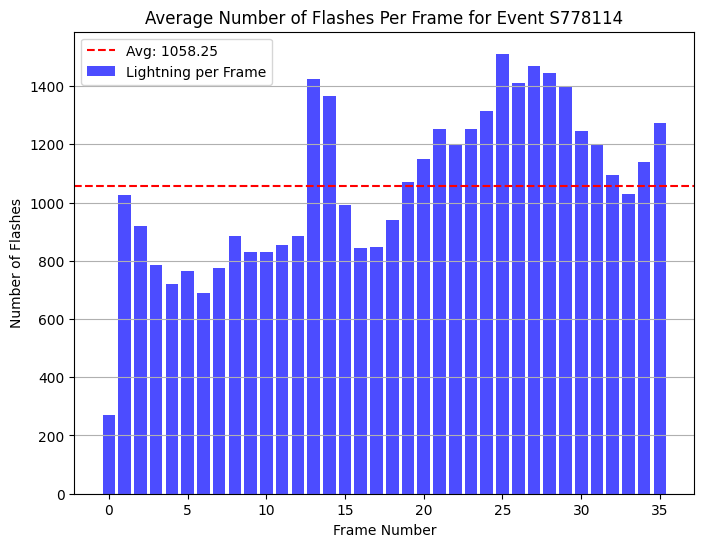

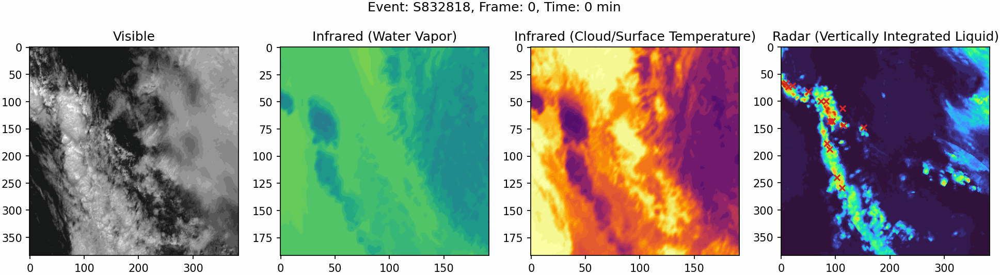

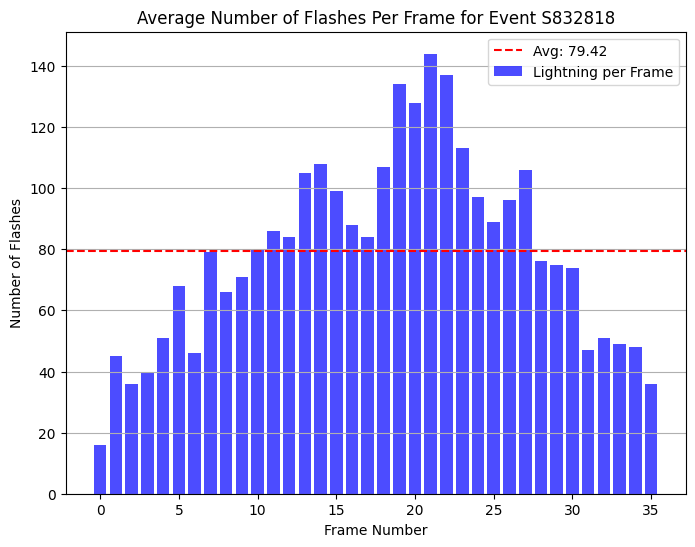

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
import IPython

def make_gif(outfile, files, fps=10, loop=0):
    """Helper function for saving GIFs"""
    imgs = [Image.open(file) for file in files]
    imgs[0].save(fp=outfile, format='gif', append_images=imgs[1:], save_all=True, duration=int(1000 / fps), loop=loop)
    im = IPython.display.Image(filename=outfile)
    im.reload()
    return im

def plot_event(id, output_gif=False, save_gif=False):
    """Helper function for plotting an event"""
    event = load_event(id)
    t = event["lght"][:, 0]  # time of lightning strike (in seconds relative to first frame)
    lightning_counts = []  # Store lightning counts for averaging
    
    def plot_frame(ti):
        f = (t >= ti * 5 * 60 - 2.5 * 60) & (t < ti * 5 * 60 + 2.5 * 60)  # Find lightning strikes in current frame
        lightning_counts.append(f.sum())  # Count lightning strikes in this frame
        fig, axs = plt.subplots(1, 4, figsize=(16, 4))
        fig.suptitle(f"Event: {id}, Frame: {ti}, Time: {ti * 5} min")
        axs[0].imshow(event["vis"][:, :, ti], vmin=0, vmax=10000, cmap="gray"), axs[0].set_title('Visible')
        axs[1].imshow(event["ir069"][:, :, ti], vmin=-8000, vmax=-1000, cmap="viridis"), axs[1].set_title('Infrared (Water Vapor)')
        axs[2].imshow(event["ir107"][:, :, ti], vmin=-7000, vmax=2000, cmap="inferno"), axs[2].set_title('Infrared (Cloud/Surface Temperature)')
        axs[3].imshow(event["vil"][:, :, ti], vmin=0, vmax=255, cmap="turbo"), axs[3].set_title('Radar (Vertically Integrated Liquid)')
        axs[3].scatter(event["lght"][f, 3], event["lght"][f, 4], marker="x", s=30, c="tab:red")
        axs[3].set_xlim(0, 384), axs[3].set_ylim(384, 0)
        if output_gif:
            file = f"_temp_{id}_{ti}.png"
            fig.savefig(file, bbox_inches="tight", dpi=150, pad_inches=0.02, facecolor="white")
            plt.close()
        else:
            plt.show()

    if output_gif:
        for ti in range(36):
            plot_frame(ti)
        # Create and save GIF
        im = make_gif(f"{id}.gif", [f"_temp_{id}_{ti}.png" for ti in range(36)])
        for ti in range(36):
            os.remove(f"_temp_{id}_{ti}.png")
        IPython.display.display(im)
        if not save_gif:
            os.remove(f"{id}.gif")
    else:
        plot_frame(0)
        plot_frame(17)
        plot_frame(34)

    # Plot the average number of lightning strikes per frame
    avg_lightning = np.mean(lightning_counts)
    plt.figure(figsize=(8, 6))
    plt.bar(range(len(lightning_counts)), lightning_counts, alpha=0.7, color='blue', label='Lightning per Frame')
    plt.axhline(avg_lightning, color='red', linestyle='--', label=f'Avg: {avg_lightning:.2f}')
    plt.title(f"Average Number of Flashes Per Frame for Event {id}")
    plt.xlabel("Frame Number")
    plt.ylabel("Number of Flashes")
    plt.legend()
    plt.grid(axis="y")
    plt.show()

plot_event("S778114", output_gif=True, save_gif=True)
plot_event("S832818", output_gif=True, save_gif=True)

Average Lightning Flashes per Frame for All Events:
Event S778114: 1058.25
Event S767475: 909.81
Event S771210: 46.33
Event S782022: 220.25
Event S769788: 210.83
Event S782134: 97.86
Event S780339: 388.06
Event S780175: 48.58
Event S769599: 33.53
Event S780322: 58.47
Event S779978: 79.17
Event S779481: 73.50
Event S786332: 78.08
Event S768254: 60.11
Event S780325: 91.83
Event S772799: 129.64
Event S781628: 476.75
Event S772454: 143.06
Event S781919: 104.33
Event S770037: 191.36
Event S777654: 159.97
Event S786356: 137.75
Event S779509: 16.78
Event S771097: 640.17
Event S786359: 55.61
Event S783140: 315.64
Event S769394: 168.17
Event S772029: 528.64
Event S770056: 201.67
Event S781525: 569.17
Event S778991: 258.56
Event S769170: 172.39
Event S786445: 91.19
Event S785820: 687.47
Event S782631: 207.17
Event S769250: 0.36
Event S772400: 370.42
Event S775278: 92.64
Event S771100: 483.36
Event S772429: 902.75
Event S782637: 194.58
Event S779911: 493.56
Event S773275: 364.00
Event S772050: 60

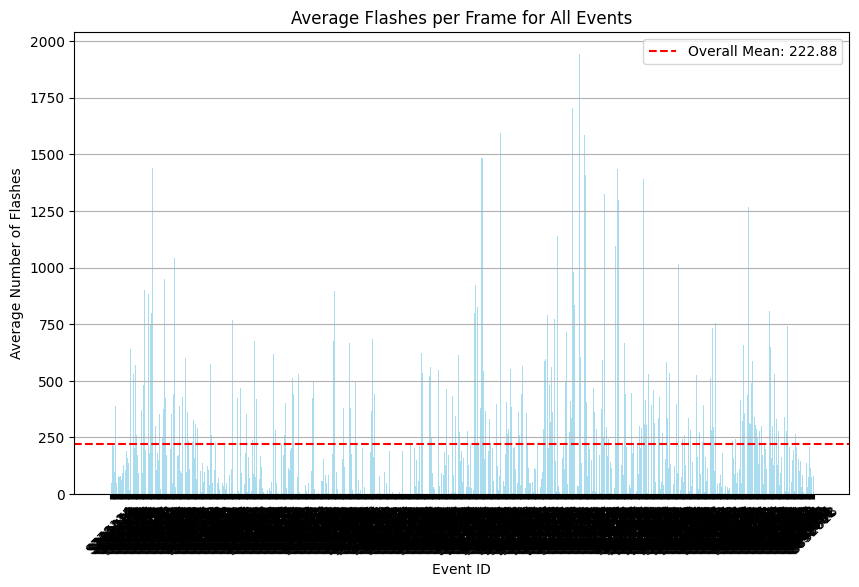

In [71]:
def calculate_average_flashes_all_ids(event_ids):
    averages = {}

    for event_id in event_ids:
        # Load event data
        event = load_event(event_id)
        t = event["lght"][:, 0]  # Time of lightning strike (in seconds relative to first frame)
        lightning_counts = []  # Store lightning counts per frame for averaging
        
        # Calculate lightning counts for all frames
        for ti in range(36):  # Assuming 36 frames per event
            f = (t >= ti * 5 * 60 - 2.5 * 60) & (t < ti * 5 * 60 + 2.5 * 60)  # Lightning strikes in current frame
            lightning_counts.append(f.sum())
        
        # Compute the average for the event
        averages[event_id] = np.mean(lightning_counts)

    # Calculate overall mean
    overall_mean = np.mean(list(averages.values()))  # Mean of event averages

    # Display summary results
    print("Average Lightning Flashes per Frame for All Events:")
    for event_id, avg in averages.items():
        print(f"Event {event_id}: {avg:.2f}")
    print(f"\nOverall Mean of Averages: {overall_mean:.2f}")

    return averages, overall_mean

event_ids = df["id"].unique().tolist()  # Extract unique IDs from the DataFrame
averages, overall_mean = calculate_average_flashes_all_ids(event_ids)

# Plot the overall mean
plt.figure(figsize=(10, 6))
plt.bar(averages.keys(), averages.values(), color="skyblue", alpha=0.7)
plt.axhline(overall_mean, color='red', linestyle='--', label=f'Overall Mean: {overall_mean:.2f}')
plt.title("Average Flashes per Frame for All Events")
plt.xlabel("Event ID")
plt.ylabel("Average Number of Flashes")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis="y")
plt.show()


In [8]:
# Let's look at the lightning data for an event
pd.DataFrame(data=event["lght"], columns=["t", "lat (deg)", "lon (deg)", "vil pixel x", "vil pixel y"]).sort_values("t")

,t,lat (deg),lon (deg),vil pixel x,vil pixel y
0,0.0,35.221024,-91.398697,97.144623,277.964905
1,0.0,35.011932,-91.927162,50.720562,251.529099
2,0.0,35.162552,-91.867744,55.068687,268.602295
3,0.0,34.954666,-92.266518,20.261250,243.241348
4,1.0,33.350700,-91.901527,64.372375,67.255501
...,...,...,...,...,...
38771,10789.0,33.844326,-89.936607,241.919693,135.542786
38772,10789.0,34.324982,-91.087601,132.307999,180.527847
38774,10789.0,32.980812,-91.671333,88.275497,27.597750
38775,10799.0,34.808228,-90.717125,162.251617,236.698776


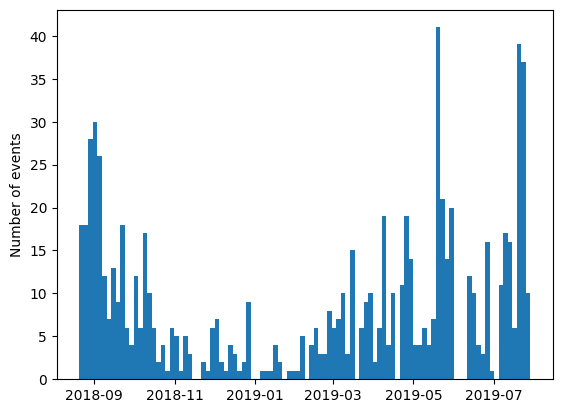

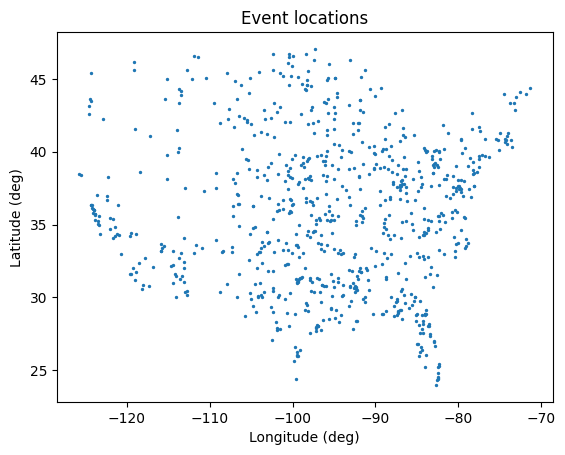

In [9]:
# let's plot some meta data histograms!

# plot times
plt.hist(df[df.img_type=="vil"].start_utc.dt.tz_localize(None), bins=100)
plt.ylabel("Number of events")
plt.show()

# plot positions
plt.title("Event locations")
plt.scatter(df[df.img_type=="vil"].llcrnrlon, df[df.img_type=="vil"].llcrnrlat, s=2)
plt.xlabel("Longitude (deg)"); plt.ylabel("Latitude (deg)")
plt.show()

In [20]:
df["img_type"].unique()

array(['ir069', 'ir107', 'lght', 'vil', 'vis'], dtype=object)

In [47]:
# Get the unique img_type values
unique_img_types = df["img_type"].unique()

# Display the DataFrame for each img_type
for img_type in unique_img_types:
    print(f"DataFrame for img_type = {img_type}")
    display(df[df["img_type"] == img_type])  

# Now let's plot for each dataframe 

DataFrame for img_type = ir069


,id,img_type,start_utc,llcrnrlat,llcrnrlon,urcrnrlat,urcrnrlon,proj,height_m,width_m
0,S778114,ir069,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.944590,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
5,S767475,ir069,2018-08-20 21:30:00+00:00,31.033963,-94.478926,34.278308,-90.155429,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
10,S771210,ir069,2018-08-20 21:40:00+00:00,43.590658,-115.365948,47.574769,-111.410627,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
15,S782022,ir069,2018-08-21 00:20:00+00:00,30.151476,-112.772184,34.032528,-109.229161,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
20,S769788,ir069,2018-08-21 17:10:00+00:00,38.392362,-81.327737,41.014591,-75.941131,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
...,...,...,...,...,...,...,...,...,...,...
3975,S842315,ir069,2019-07-27 22:49:00+00:00,41.179232,-104.697152,44.801192,-100.227097,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3980,S843992,ir069,2019-07-27 23:44:00+00:00,41.509618,-113.935676,45.443111,-109.997834,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3985,S831751,ir069,2019-07-28 16:29:00+00:00,27.535322,-97.939401,30.924864,-93.917514,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3990,S843692,ir069,2019-07-28 17:34:00+00:00,44.065108,-72.519391,46.171265,-66.147719,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0


DataFrame for img_type = ir107


,id,img_type,start_utc,llcrnrlat,llcrnrlon,urcrnrlat,urcrnrlon,proj,height_m,width_m
1,S778114,ir107,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.944590,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
6,S767475,ir107,2018-08-20 21:30:00+00:00,31.033963,-94.478926,34.278308,-90.155429,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
11,S771210,ir107,2018-08-20 21:40:00+00:00,43.590658,-115.365948,47.574769,-111.410627,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
16,S782022,ir107,2018-08-21 00:20:00+00:00,30.151476,-112.772184,34.032528,-109.229161,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
21,S769788,ir107,2018-08-21 17:10:00+00:00,38.392362,-81.327737,41.014591,-75.941131,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
...,...,...,...,...,...,...,...,...,...,...
3976,S842315,ir107,2019-07-27 22:49:00+00:00,41.179232,-104.697152,44.801192,-100.227097,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3981,S843992,ir107,2019-07-27 23:44:00+00:00,41.509618,-113.935676,45.443111,-109.997834,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3986,S831751,ir107,2019-07-28 16:29:00+00:00,27.535322,-97.939401,30.924864,-93.917514,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3991,S843692,ir107,2019-07-28 17:34:00+00:00,44.065108,-72.519391,46.171265,-66.147719,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0


DataFrame for img_type = lght


,id,img_type,start_utc,llcrnrlat,llcrnrlon,urcrnrlat,urcrnrlon,proj,height_m,width_m
2,S778114,lght,NaT,32.781533,-92.631841,35.944590,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
7,S767475,lght,NaT,31.033963,-94.478926,34.278308,-90.155429,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
12,S771210,lght,NaT,43.590658,-115.365948,47.574769,-111.410627,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
17,S782022,lght,NaT,30.151476,-112.772184,34.032528,-109.229161,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
22,S769788,lght,NaT,38.392362,-81.327737,41.014591,-75.941131,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
...,...,...,...,...,...,...,...,...,...,...
3977,S842315,lght,NaT,41.179232,-104.697152,44.801192,-100.227097,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3982,S843992,lght,NaT,41.509618,-113.935676,45.443111,-109.997834,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3987,S831751,lght,NaT,27.535322,-97.939401,30.924864,-93.917514,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3992,S843692,lght,NaT,44.065108,-72.519391,46.171265,-66.147719,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0


DataFrame for img_type = vil


,id,img_type,start_utc,llcrnrlat,llcrnrlon,urcrnrlat,urcrnrlon,proj,height_m,width_m
3,S778114,vil,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.944590,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
8,S767475,vil,2018-08-20 21:30:00+00:00,31.033963,-94.478926,34.278308,-90.155429,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
13,S771210,vil,2018-08-20 21:40:00+00:00,43.590658,-115.365948,47.574769,-111.410627,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
18,S782022,vil,2018-08-21 00:20:00+00:00,30.151476,-112.772184,34.032528,-109.229161,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
23,S769788,vil,2018-08-21 17:10:00+00:00,38.392362,-81.327737,41.014591,-75.941131,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
...,...,...,...,...,...,...,...,...,...,...
3978,S842315,vil,2019-07-27 22:50:00+00:00,41.179232,-104.697152,44.801192,-100.227097,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3983,S843992,vil,2019-07-27 23:45:00+00:00,41.509618,-113.935676,45.443111,-109.997834,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3988,S831751,vil,2019-07-28 16:30:00+00:00,27.535322,-97.939401,30.924864,-93.917514,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3993,S843692,vil,2019-07-28 17:35:00+00:00,44.065108,-72.519391,46.171265,-66.147719,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0


DataFrame for img_type = vis


,id,img_type,start_utc,llcrnrlat,llcrnrlon,urcrnrlat,urcrnrlon,proj,height_m,width_m
4,S778114,vis,2018-08-20 19:50:00+00:00,32.781533,-92.631841,35.944590,-88.134075,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
9,S767475,vis,2018-08-20 21:30:00+00:00,31.033963,-94.478926,34.278308,-90.155429,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
14,S771210,vis,2018-08-20 21:40:00+00:00,43.590658,-115.365948,47.574769,-111.410627,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
19,S782022,vis,2018-08-21 00:20:00+00:00,30.151476,-112.772184,34.032528,-109.229161,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
24,S769788,vis,2018-08-21 17:10:00+00:00,38.392362,-81.327737,41.014591,-75.941131,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
...,...,...,...,...,...,...,...,...,...,...
3979,S842315,vis,2019-07-27 22:49:00+00:00,41.179232,-104.697152,44.801192,-100.227097,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3984,S843992,vis,2019-07-27 23:44:00+00:00,41.509618,-113.935676,45.443111,-109.997834,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3989,S831751,vis,2019-07-28 16:29:00+00:00,27.535322,-97.939401,30.924864,-93.917514,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0
3994,S843692,vis,2019-07-28 17:34:00+00:00,44.065108,-72.519391,46.171265,-66.147719,+proj=laea +lat_0=38 +lon_0=-98 +units=m +a=63...,384000.0,384000.0


In [52]:
for img_type in unique_img_types:
    filtered_df = df[df["img_type"] == img_type]
    
    # Display summary statistics
    print(f"Summary Statistics for img_type = {img_type}")
    print(filtered_df.describe())
    

Summary Statistics for img_type = ir069
        llcrnrlat   llcrnrlon   urcrnrlat   urcrnrlon  height_m   width_m
count  800.000000  800.000000  800.000000  800.000000     800.0     800.0
mean    35.798102  -95.540783   39.031850  -90.966831  384000.0  384000.0
std      5.152912   12.037813    5.170318   12.598800       0.0       0.0
min     23.992945 -125.744242   26.783679 -122.647604  384000.0  384000.0
25%     31.575832 -102.280406   34.896374  -97.933196  384000.0  384000.0
50%     35.747651  -95.178018   39.286816  -90.513645  384000.0  384000.0
75%     39.495722  -86.244292   42.617157  -81.145934  384000.0  384000.0
max     47.054793  -71.300576   50.443499  -64.835639  384000.0  384000.0
Summary Statistics for img_type = ir107
        llcrnrlat   llcrnrlon   urcrnrlat   urcrnrlon  height_m   width_m
count  800.000000  800.000000  800.000000  800.000000     800.0     800.0
mean    35.798102  -95.540783   39.031850  -90.966831  384000.0  384000.0
std      5.152912   12.037813   

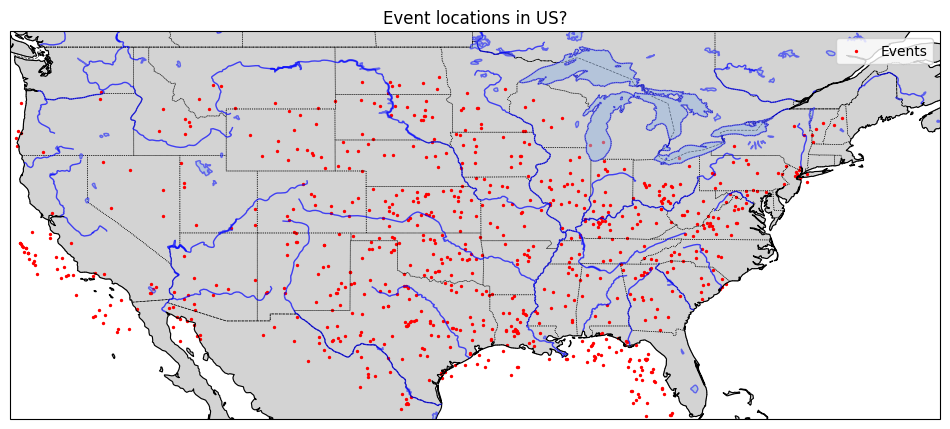

In [58]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Ensure your data is loaded into a DataFrame called df
# Filter for "vil" img_type
vil_data = df[df["img_type"] == "vil"]

# Create a plot with Cartopy
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())  # Use PlateCarree projection for latitude/longitude
ax.set_extent([-125, -65, 25, 50], crs=ccrs.PlateCarree())  # Focus on the US region

# Add map features
ax.add_feature(cfeature.LAND, color='lightgrey')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle='--', linewidth=0.5)
ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.LAKES, edgecolor='blue', alpha=0.5)
ax.add_feature(cfeature.RIVERS, edgecolor='blue', alpha=0.7)

# Plot the lightning event locations
plt.scatter(vil_data["llcrnrlon"], vil_data["llcrnrlat"], s=2, color="red", transform=ccrs.PlateCarree(), label="Events")

# Add title and labels
plt.title("Event locations in US?")
plt.legend(loc="upper right", fontsize=10)
plt.show()